In [1]:
import numpy as np
import pandas as pd

import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import myutils

import os

sc.settings.verbosity = 3
myutils.set_figure_params()

C:\Users\dell\.conda\envs\scanpy\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad("1.2.keloid_merge_preprocessed.h5ad")
adata

AnnData object with n_obs × n_vars = 178555 × 30780
    obs: 'cell_id', 'sample', 'batch', 'condition', 'condition2', 'description', 'path', 'file_format', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'doublet_label', 'doublet_score'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
sc.tl.leiden(adata,resolution=0.6)

running Leiden clustering


C:\Users\dell\AppData\Local\Temp\ipykernel_32804\2288680387.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata,resolution=0.6)


    finished: found 22 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:24)


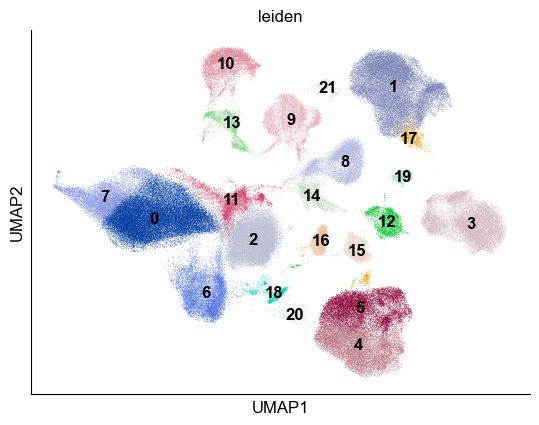

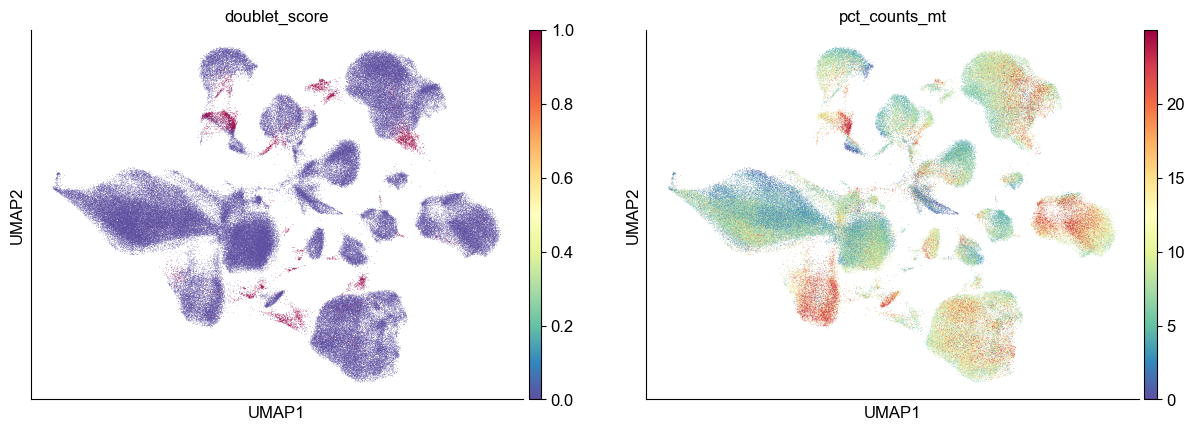

In [4]:
sc.pl.umap(adata,color=["leiden"],legend_loc="on data")
sc.pl.umap(adata,color=["doublet_score","pct_counts_mt"])

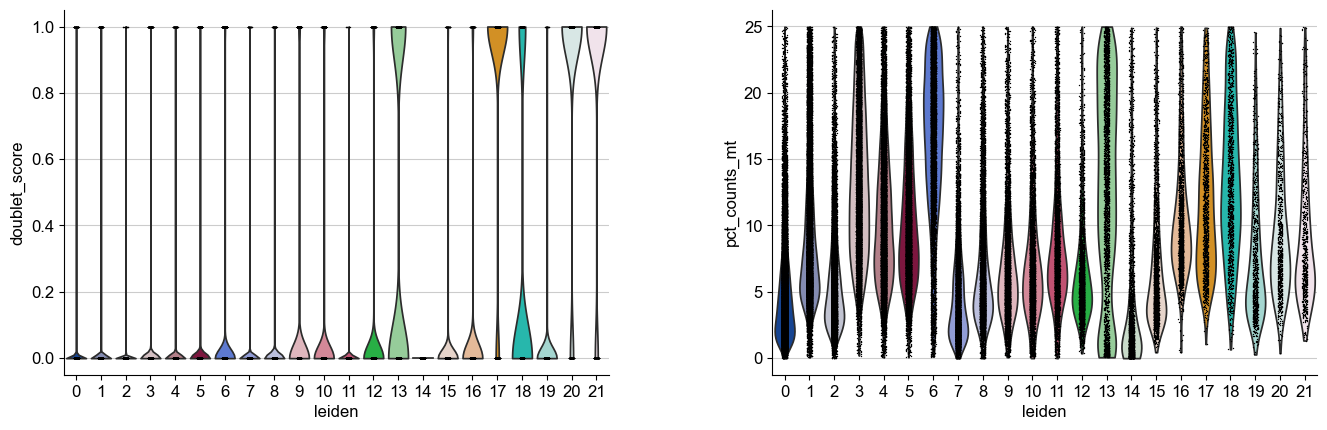

In [5]:
sc.pl.violin(adata,["doublet_score","pct_counts_mt"],groupby="leiden")

In [11]:
#cluster "6","18","20","17","13","14","21" was removed by doublets filetering or high fraction of mito genes expression
adata = adata[~adata.obs['leiden'].isin(["6","18","20","17","13","14","21"])]
adata

View of AnnData object with n_obs × n_vars = 159431 × 30780
    obs: 'cell_id', 'sample', 'batch', 'condition', 'condition2', 'description', 'path', 'file_format', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'doublet_label', 'doublet_score', 'leiden', 'CellType_rough'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'leiden', 'leiden_colors', 'CellType_rough_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [12]:
markers = {"Macro":["LYZ","AIF1","HLA-DRA","CD68","ITGAX","CD207","CD1A"],
          "Keratinocytes":["KRT1","KRT10","SBSN","KRTDAP","KRT14","KRT5","TP63","ITGA6"],
          "EC":["VWF","SELE","CLDN5","CDH5","LYVE1","PROX1"],
          "Fibro":["COL1A2","LUM","DCN","VIM","PDGFRA"],
          "Peicytes":["ACTA2","RGS5","PDGFRB"],
          "Erythrocytes":["HBA1","HBA2","HBB"],
          "Melanocytes":["PMEL","MLANA","TYRP1","DCT"],
          "B cell":["JCHAIN", "CD79A"],
          "Mast cell":["CPA3", "TPSAB1","TPSB2"],
          "Neuron":["NRXN1"],
          "T":["CD3D","CD3G","CD3E"],
          "Sweat Gland Cells":["SCGB1B2P","SCGB1D2"],
          "Melanocyte":["MLANA","DCT","PMEL"]}

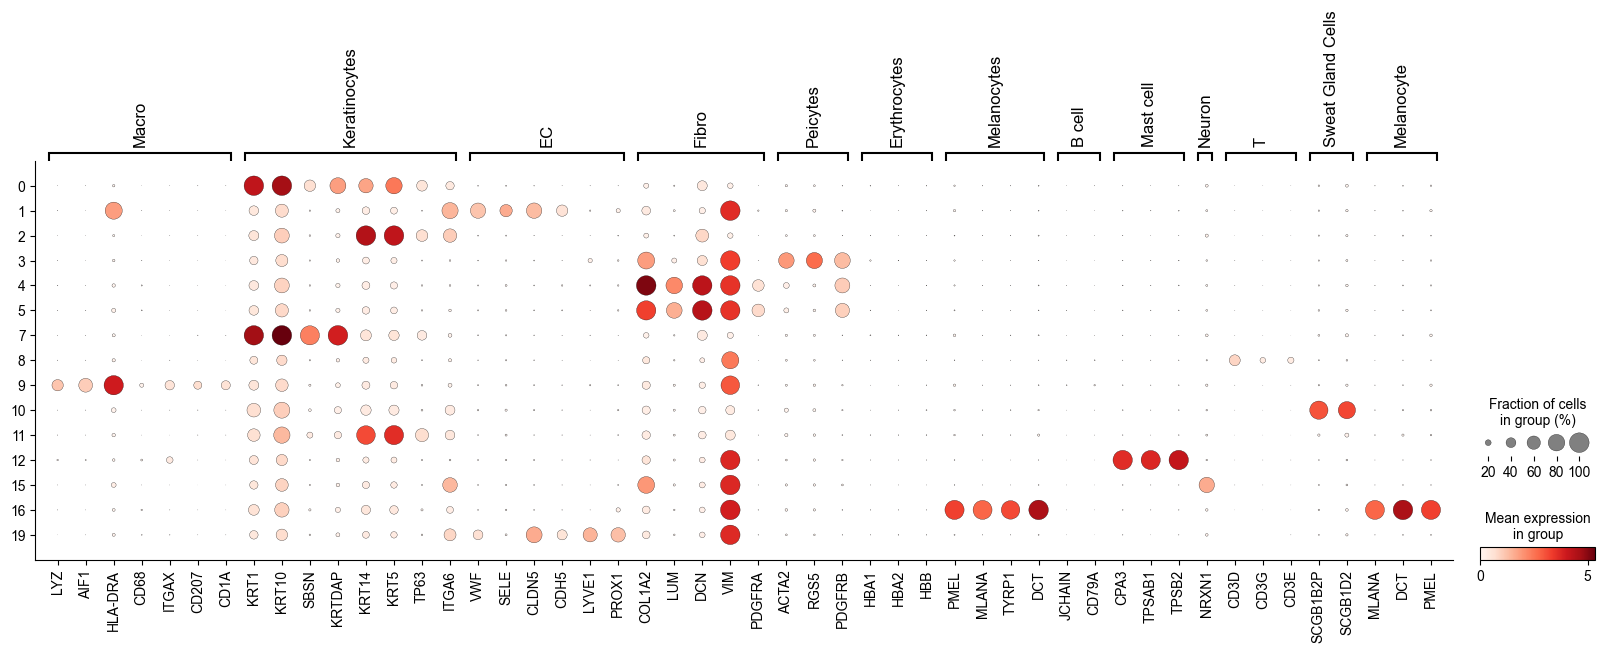

In [13]:
sc.pl.dotplot(adata, markers,groupby="leiden")

In [14]:
CellType_rough = {"Fibroblast":["4","5"],
            "Pericyte":["3"],
            "Sweat Gland Cell":["10"],
            "T Cell":["8"],
            "Myeloid Cell":["9"],
            "Melanocyte":["16"],
            "Mast Cell":["12"],
            "Neuron":["15"],
           "Endothelial Cell":["1"],
            "Lymphatic Endothelial cell":["19"],
            "Keratinocyte":["7","0","2","11"]}

In [15]:
myutils.tl.annotate_cell(adata,key_column="leiden",CellType=CellType_rough)

C:\Users\dell\.conda\envs\scanpy\lib\site-packages\myutils\_tools\_tl.py:193: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[new_column] = "Others"
C:\Users\dell\.conda\envs\scanpy\lib\site-packages\myutils\_tools\_tl.py:196: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https:/

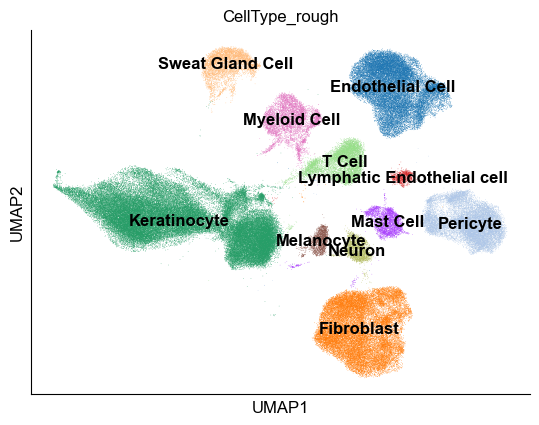

In [16]:
sc.pl.umap(adata,color=["CellType"],legend_loc="on data")

In [ ]:
adata.write_h5ad("1.3.final_all.h5ad")

In [17]:
adata2 = sc.read_h5ad("1.3.final_all_for_open_access.h5ad")
adata2

AnnData object with n_obs × n_vars = 166418 × 25998
    obs: 'cell_id', 'sample', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'condition', 'leiden', 'CellType', 'condition_final'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_colors', 'batch_colors', 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [18]:
inter_index = np.intersect1d(adata.obs_names,adata2.obs_names)
inter_index.shape

(156696,)

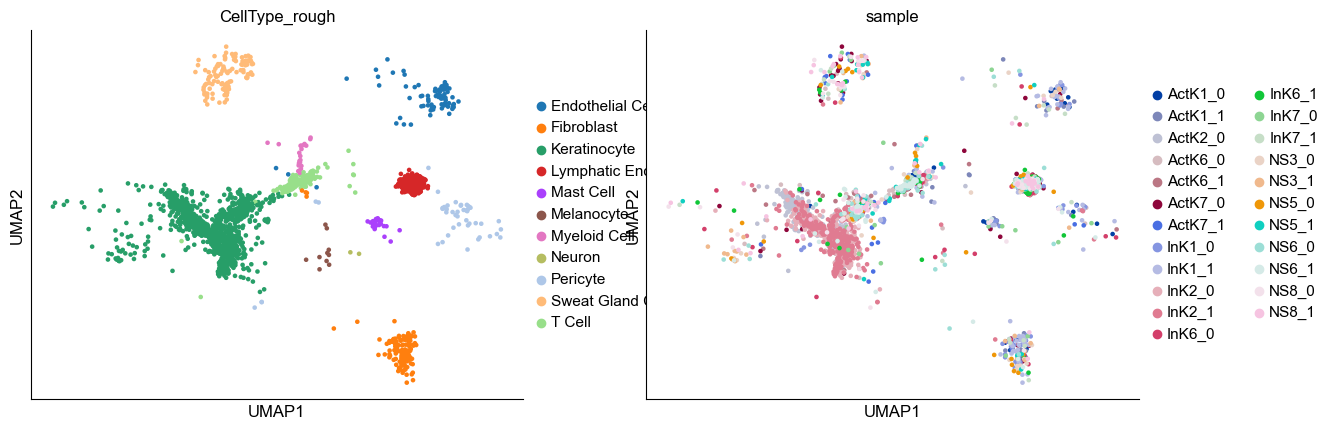

In [24]:
sc.pl.umap(adata[~adata.obs_names.isin(inter_index)],color=["CellType_rough","sample"])

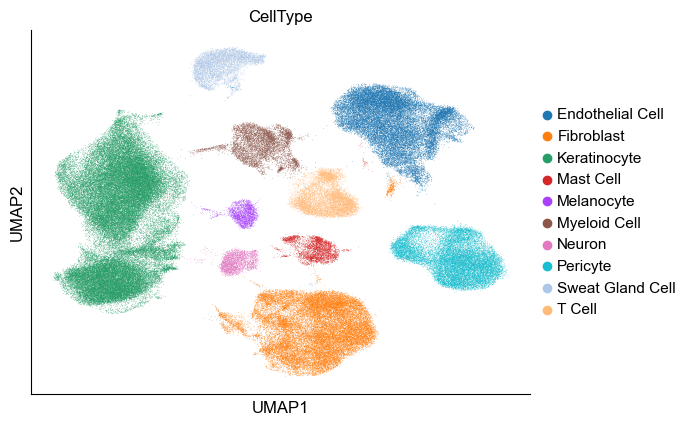

In [28]:
sc.pl.umap(adata2,color="CellType")

# Environments

In [29]:
! conda list

# packages in environment at C:\Users\dell\.conda\envs\scanpy:
#
# Name                    Version                   Build  Channel
absl-py                   2.3.0                    pypi_0    pypi
adjusttext                1.3.0                    pypi_0    pypi
aiobotocore               2.5.4                    pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.12.4                   pypi_0    pypi
aioitertools              0.12.0                   pypi_0    pypi
aiosignal                 1.3.2                    pypi_0    pypi
anndata                   0.10.8                   pypi_0    pypi
anyio                     4.8.0                    pypi_0    pypi
argon2-cffi               23.1.0                   pypi_0    pypi
argon2-cffi-bindings      21.2.0                   pypi_0    pypi
array-api-compat          1.10.0                   pypi_0    pypi
arrow                     1.3.0                    pypi_0    pypi
asciitree 